In [1]:
import parmed as pmd
import torch
import numpy as np
from system.topology import Topology
from forces.twobody import MixtureLJ, Harmonic_Bond, MixtureCoulomb
from forces.threebody import Harmonic_Angle
from forces.fourbody import Dihedral
import system.units as units
import system.box as box
import system.system as sys
from integrators.NVE import NVE
from integrators.NVT import NVT
from integrators.ParallelTempering import ParallelTempering
import matplotlib.pyplot as plt
import math
from tqdm import trange
from utils import *
from scipy.ndimage import gaussian_filter
dtype=torch.float32
device="cuda"


╔═══════════════════════════════════════════════════╗
║                                                   ║
║  ██████╗   ██████╗    ██╗      ██████╗   ██╗  ██╗ ║
║ ██╔════╝  ██╔══██╗   ██╔██╗    ██╔══██╗  ██║ ██╔╝ ║
║ ╚█████╗   ██████╔╝  ██╔╝╚██╗   ██████╔╝  █████╔╝  ║
║  ╚═══██╗  ██╔═══╝  ██╔╝  ╚██╗  ██╔══██╗  ██╔═██╗  ║
║ ██████╔╝  ██║     ██╔╝    ╚██╗ ██║  ██║  ██║ ╚██╗ ║
║ ╚═════╝   ╚═╝     ╚═╝      ╚═╝ ╚═╝  ╚═╝  ╚═╝  ╚═╝ ║
║                                                   ║
║     Statistical Physics Autodiff Research Kit     ║
╚═══════════════════════════════════════════════════╝

          V(r)           ψ, φ              q
           │               │               │
           ○               ○               ○
         ╱ | ╲           ╱ | ╲           ╱ | ╲
        ○  ○  ○         ○  ○  ○         ○  ○  ○
         ╲ | ╱           ╲ | ╱           ╲ | ╱
           ○               ○               ○
           │               │               │
          g(r)             F         

In [2]:
top, node_features, mass, energy_dict = build_top_and_features("alanine-dipeptide.prmtop")
B = 4*4096
pos = torch.tensor(pmd.load_file("alanine-dipeptide.pdb").coordinates,dtype=dtype,device=device).unsqueeze(0).expand(B, -1, -1).contiguous()
atomic_numbers = [a.atomic_number for a in pmd.load_file("alanine-dipeptide.pdb").atoms]
b = box.Box([1000,1000,1000],["s","s","s"])
u = units.UnitSystem.akma()
mom = 0.5*torch.randn_like(pos)

S = sys.System(pos, mom, mass, top, b, energy_dict, u, node_features)
S._potential_energy(pos)
S.compile_force_fn()
S.pos = S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1)

# 298K

In [3]:
integrator = NVT(0.005, 20, 298)
print(integrator)

steps = 100_000
skip = 200
positions_LowT = torch.empty((int(steps / skip), B, 22, 3), device=device)

with torch.no_grad():
    for i in trange(steps, desc="Running simulation"):
        if i % skip == 0:
            positions_LowT[int(i / skip)] = S.pos
        integrator.step(S)
        S.pos = S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1)

NVT(dt=0.005, gamma=20, T=298)


Running simulation: 100%|█████████████████████████████████████████████████████████████████████| 100000/100000 [11:13<00:00, 148.49it/s]


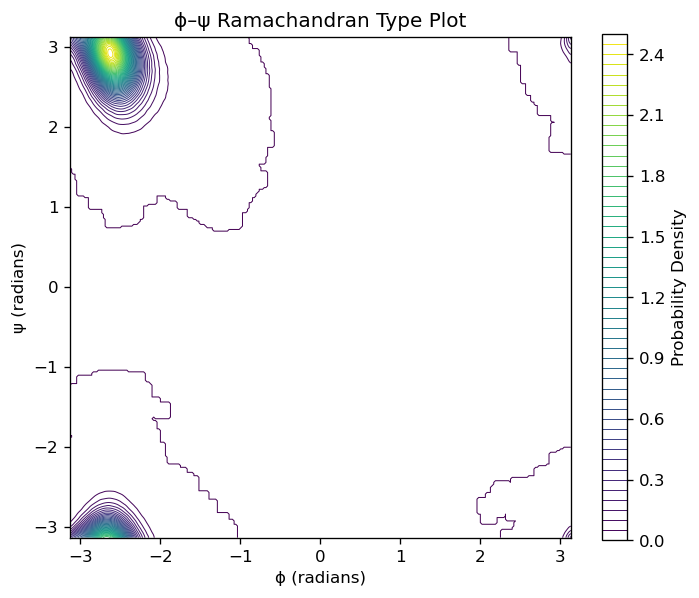

In [4]:
bins = 300
extent = [-math.pi, math.pi, -math.pi, math.pi]
range_ = [extent[:2], extent[2:]]

# Compute and smooth histogram
dihedrals = compute_dihedrals(positions_LowT, top.get_tensor(4, 'dihtype_6'))  # (T, M, 2)
data = dihedrals.reshape(-1, 2).cpu().numpy()
hist, _, _ = np.histogram2d(data[:, 0], data[:, 1], bins=bins, range=range_, density=True)
hist_smooth = gaussian_filter(hist, sigma=1.0)

# Create clean line contour plot
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
contours = ax.contour(
    hist_smooth, levels=50, linewidths=0.6, cmap='viridis',
    extent=extent, origin='lower', antialiased=True
)
cb = fig.colorbar(contours, ax=ax, label="Probability Density")

ax.set_xlabel("ϕ (radians)")
ax.set_ylabel("ψ (radians)")
ax.set_title("ϕ–ψ Ramachandran Type Plot")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# 1000 K

In [5]:
integrator = NVT(0.005, 20, 1000)
print(integrator)

steps = 100_000
skip = 200
positions_HighT = torch.empty((int(steps / skip), B, 22, 3), device=device)

with torch.no_grad():
    for i in trange(steps, desc="Running simulation"):
        if i % skip == 0:
            positions_HighT[int(i / skip)] = S.pos
        integrator.step(S)
        S.pos = S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1)

NVT(dt=0.005, gamma=20, T=1e+03)


Running simulation: 100%|█████████████████████████████████████████████████████████████████████| 100000/100000 [10:56<00:00, 152.32it/s]


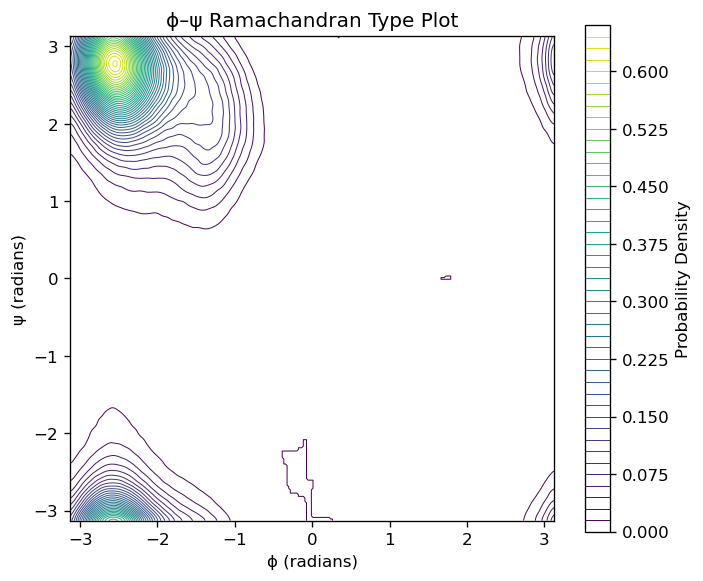

In [6]:
bins = 300
extent = [-math.pi, math.pi, -math.pi, math.pi]
range_ = [extent[:2], extent[2:]]

# Compute and smooth histogram
dihedrals = compute_dihedrals(positions_HighT, top.get_tensor(4, 'dihtype_6'))  # (T, M, 2)
data = dihedrals.reshape(-1, 2).cpu().numpy()
hist, _, _ = np.histogram2d(data[:, 0], data[:, 1], bins=bins, range=range_, density=True)
hist_smooth = gaussian_filter(hist, sigma=2.0)

# Create clean line contour plot
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
contours = ax.contour(
    hist_smooth, levels=50, linewidths=0.6, cmap='viridis',
    extent=extent, origin='lower', antialiased=True
)
cb = fig.colorbar(contours, ax=ax, label="Probability Density")

ax.set_xlabel("ϕ (radians)")
ax.set_ylabel("ψ (radians)")
ax.set_title("ϕ–ψ Ramachandran Type Plot")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


# Parallel Tempering

In [7]:
n_blocks = 8 # number of temperatures between low T and High T
D = B // n_blocks
T = torch.linspace(298, 1000, n_blocks, device=device, dtype=dtype).repeat_interleave(D)
integrator_PT = ParallelTempering(0.005, 20, T, D)
steps = 100_000
skip = 100
positions_PT = torch.empty((int(steps / skip), B, 22, 3), device=device)
swap = 500
with torch.no_grad():
    for i in trange(steps, desc="Running simulation"):
        if i % skip == 0:
            positions_PT[int(i / skip)] = S.pos 
        integrator_PT.step_NVT(S)
        if i % swap == 0:
            integrator_PT.swap(S)
        if i % 10_000 ==0:
            print("% Of accepted swaps =", integrator_PT.last_accept_percent)
        S.pos = S.pos - (S.mass.unsqueeze(-1) * S.pos).sum(dim=1, keepdim=True) / S.mass.sum(dim=1, keepdim=True).unsqueeze(-1)

Running simulation:   0%|                                                                          | 18/100000 [00:00<19:31, 85.34it/s]

% Of accepted swaps = 0.6923828125


Running simulation:  10%|███████                                                               | 10021/100000 [01:06<09:53, 151.73it/s]

% Of accepted swaps = 0.521484375


Running simulation:  20%|██████████████                                                        | 20020/100000 [02:12<08:46, 151.81it/s]

...

Running simulation:  80%|████████████████████████████████████████████████████████              | 80016/100000 [08:48<02:42, 123.11it/s]

% Of accepted swaps = 0.5250244140625


Running simulation:  90%|███████████████████████████████████████████████████████████████       | 90021/100000 [09:55<01:08, 144.78it/s]

% Of accepted swaps = 0.515625


Running simulation: 100%|█████████████████████████████████████████████████████████████████████| 100000/100000 [11:00<00:00, 151.34it/s]


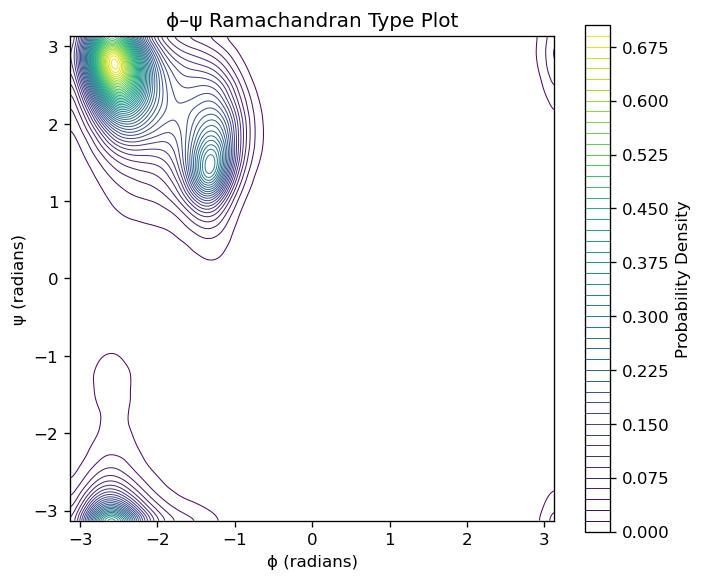

In [30]:
bins = 300
extent = [-math.pi, math.pi, -math.pi, math.pi]
range_ = [extent[:2], extent[2:]]

# Compute and smooth histogram
dihedrals = compute_dihedrals(positions_PT[:900], top.get_tensor(4, 'dihtype_6'))  # (T, M, 2)
data = dihedrals.reshape(-1, 2).cpu().numpy()
hist, _, _ = np.histogram2d(data[:, 0], data[:, 1], bins=bins, range=range_, density=True)
hist_smooth = gaussian_filter(hist, sigma=3.0)

# Create clean line contour plot
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
contours = ax.contour(
    hist_smooth, levels=50, linewidths=0.6, cmap='viridis',
    extent=extent, origin='lower', antialiased=True
)
cb = fig.colorbar(contours, ax=ax, label="Probability Density")

ax.set_xlabel("ϕ (radians)")
ax.set_ylabel("ψ (radians)")
ax.set_title("ϕ–ψ Ramachandran Type Plot")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

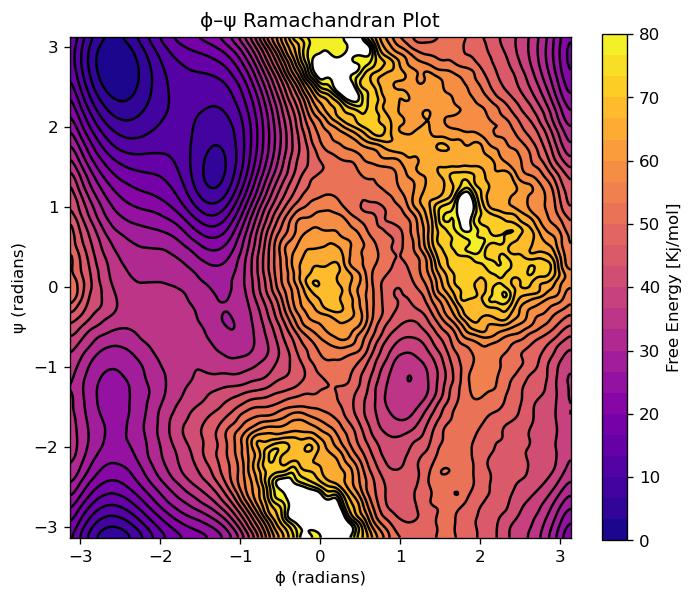

In [50]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

# Compute the free energy
F = 4.184 * (-np.log(hist_smooth) / (u.kB * 298))
F -= np.min(F)
levels = np.linspace(0, 80, 25)
linelevels = np.linspace(0, 80, 25)

# Filled contours
cf = ax.contourf(F, levels=levels, cmap='plasma', extent=extent, origin='lower')

# Optional: add contour lines on top
ax.contour(F, levels=linelevels, linewidths=1.5, colors='black', extent=extent, origin='lower')

# Colorbar
cb = fig.colorbar(cf, ax=ax, label="Free Energy [Kj/mol]")

# Labels and formatting
ax.set_xlabel("ϕ (radians)")
ax.set_ylabel("ψ (radians)")
ax.set_title("ϕ–ψ Ramachandran Plot")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [38]:
save_xyz(positions_PT[:,:2],atomic_numbers)